# Credit Card Fraud Detection - Exploratory Data Analysis

This notebook performs a comprehensive exploratory data analysis on the credit card fraud detection dataset.

**Key sections:**
- Data loading and basic exploration
- Class distribution analysis
- Distribution visualizations
- Correlation analysis


In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Section 1: Load and Explore the Dataset

Load the credit card fraud dataset from a CSV file and perform initial exploration.


In [3]:
def load_dataset(filepath: str) -> pd.DataFrame:
    """
    Load dataset from CSV file.
    
    Args:
        filepath: Path to the CSV file
        
    Returns:
        DataFrame containing the dataset
    """
    df = pd.read_csv(filepath)
    print(f"✓ Dataset loaded successfully")
    print(f"  Shape: {df.shape}")
    return df


# Load the dataset
DATA_PATH = "../Fraud.csv"  # Fraud.csv in the project root

try:
    df = load_dataset(DATA_PATH)
except FileNotFoundError:
    print(f"⚠ File not found at {DATA_PATH}")
    print("Tip: Make sure Fraud.csv is in the project root directory")
    print("For now, creating a sample dataset for demonstration...")
    # Sample creation for demonstration
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'Time': np.arange(n_samples),
        'V1': np.random.randn(n_samples),
        'V2': np.random.randn(n_samples),
        'V3': np.random.randn(n_samples),
        'V4': np.random.randn(n_samples),
        'V5': np.random.randn(n_samples),
        'Amount': np.random.exponential(100, n_samples),
        'Class': np.random.choice([0, 1], n_samples, p=[0.99, 0.01])
    })
    print("✓ Sample dataset created for demonstration")

✓ Dataset loaded successfully
  Shape: (6362620, 11)


## Section 2: Display Dataset Information

Display basic information about the dataset including shape, data types, and missing values.


In [4]:
def display_dataset_info(df: pd.DataFrame) -> None:
    """
    Display comprehensive dataset information.
    
    Args:
        df: Input DataFrame
    """
    print("\n" + "="*70)
    print("DATASET OVERVIEW")
    print("="*70)
    print(f"\n📊 Shape: {df.shape}")
    print(f"   Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    print("\n📋 First 5 Rows:")
    print(df.head())
    
    print("\n📋 Last 5 Rows:")
    print(df.tail())
    
    print("\n🔍 Data Types:")
    print(df.dtypes)
    
    print("\n❌ Missing Values:")
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("   No missing values found!")
    else:
        print(missing[missing > 0])
    
    print("\n📈 Statistical Summary:")
    print(df.describe())
    
    print("\n" + "="*70 + "\n")


# Display dataset information
display_dataset_info(df)


DATASET OVERVIEW

📊 Shape: (6362620, 11)
   Rows: 6362620, Columns: 11

📋 First 5 Rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

📋 Last 5 Rows:


## Section 3: Analyze Class Distribution

Analyze the fraud vs non-fraud transaction distribution and identify class imbalance.


In [5]:
def analyze_class_distribution(df: pd.DataFrame, target_column: str = 'isFraud') -> None:
    """
    Analyze and display class distribution.
    
    Args:
        df: Input DataFrame
        target_column: Name of the target column
    """
    print("\n" + "="*70)
    print("CLASS DISTRIBUTION ANALYSIS")
    print("="*70)
    
    # Get class distribution
    class_counts = df[target_column].value_counts().sort_index()
    class_percentages = df[target_column].value_counts(normalize=True).sort_index() * 100
    
    print(f"\n📊 Class Counts:")
    for class_label, count in class_counts.items():
        print(f"   Class {class_label}: {count:,} transactions ({class_percentages[class_label]:.2f}%)")
    
    # Calculate imbalance ratio
    if len(class_counts) == 2:
        imbalance_ratio = class_counts.iloc[1] / class_counts.iloc[0]
        print(f"\n⚠️  Class Imbalance Ratio: 1:{1/imbalance_ratio:.0f}")
        print(f"   (For every fraud case, there are {1/imbalance_ratio:.0f} normal transactions)")
    
    print("\n" + "="*70 + "\n")


# Analyze class distribution
analyze_class_distribution(df, target_column='isFraud')


CLASS DISTRIBUTION ANALYSIS

📊 Class Counts:
   Class 0: 6,354,407 transactions (99.87%)
   Class 1: 8,213 transactions (0.13%)

⚠️  Class Imbalance Ratio: 1:774
   (For every fraud case, there are 774 normal transactions)




## Section 4: Visualize Class Distribution with Countplot

Create a countplot to visualize the frequency of fraud vs non-fraud transactions.


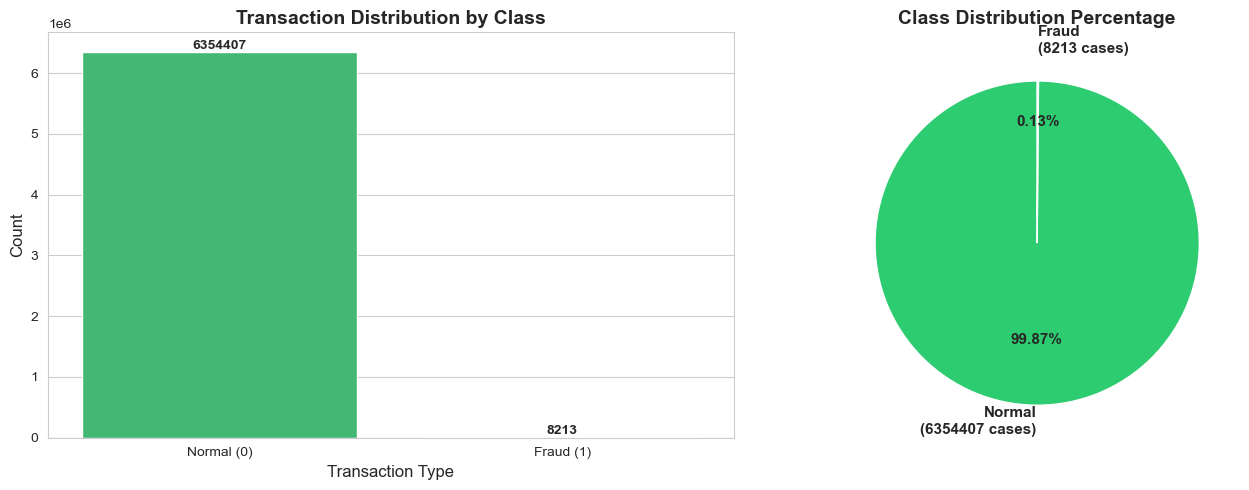

✓ Class distribution plots generated


In [6]:
def plot_class_distribution(df: pd.DataFrame, target_column: str = 'isFraud') -> None:
    """
    Create a countplot for class distribution with enhanced styling.
    
    Args:
        df: Input DataFrame
        target_column: Name of the target column
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Countplot
    counts = df[target_column].value_counts()
    colors = ['#2ecc71', '#e74c3c']  # Green for normal, Red for fraud
    
    sns.countplot(data=df, x=target_column, ax=axes[0], palette=colors, order=sorted(df[target_column].unique()))
    axes[0].set_title('Transaction Distribution by Class', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Transaction Type', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'])
    
    # Add value labels on bars
    for i, v in enumerate(counts):
        axes[0].text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    percentages = df[target_column].value_counts()
    labels = [f'Normal\n({percentages[0]} cases)', f'Fraud\n({percentages[1]} cases)']
    explode = (0.05, 0.1)
    
    axes[1].pie(percentages, labels=labels, colors=colors, autopct='%1.2f%%',
                startangle=90, explode=explode, textprops={'fontsize': 11, 'weight': 'bold'})
    axes[1].set_title('Class Distribution Percentage', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Class distribution plots generated")


# Create class distribution visualization
plot_class_distribution(df, target_column='isFraud')

## Section 5: Visualize Transaction Amount Distribution

Plot the distribution of transaction amounts separately for fraud and non-fraud transactions.


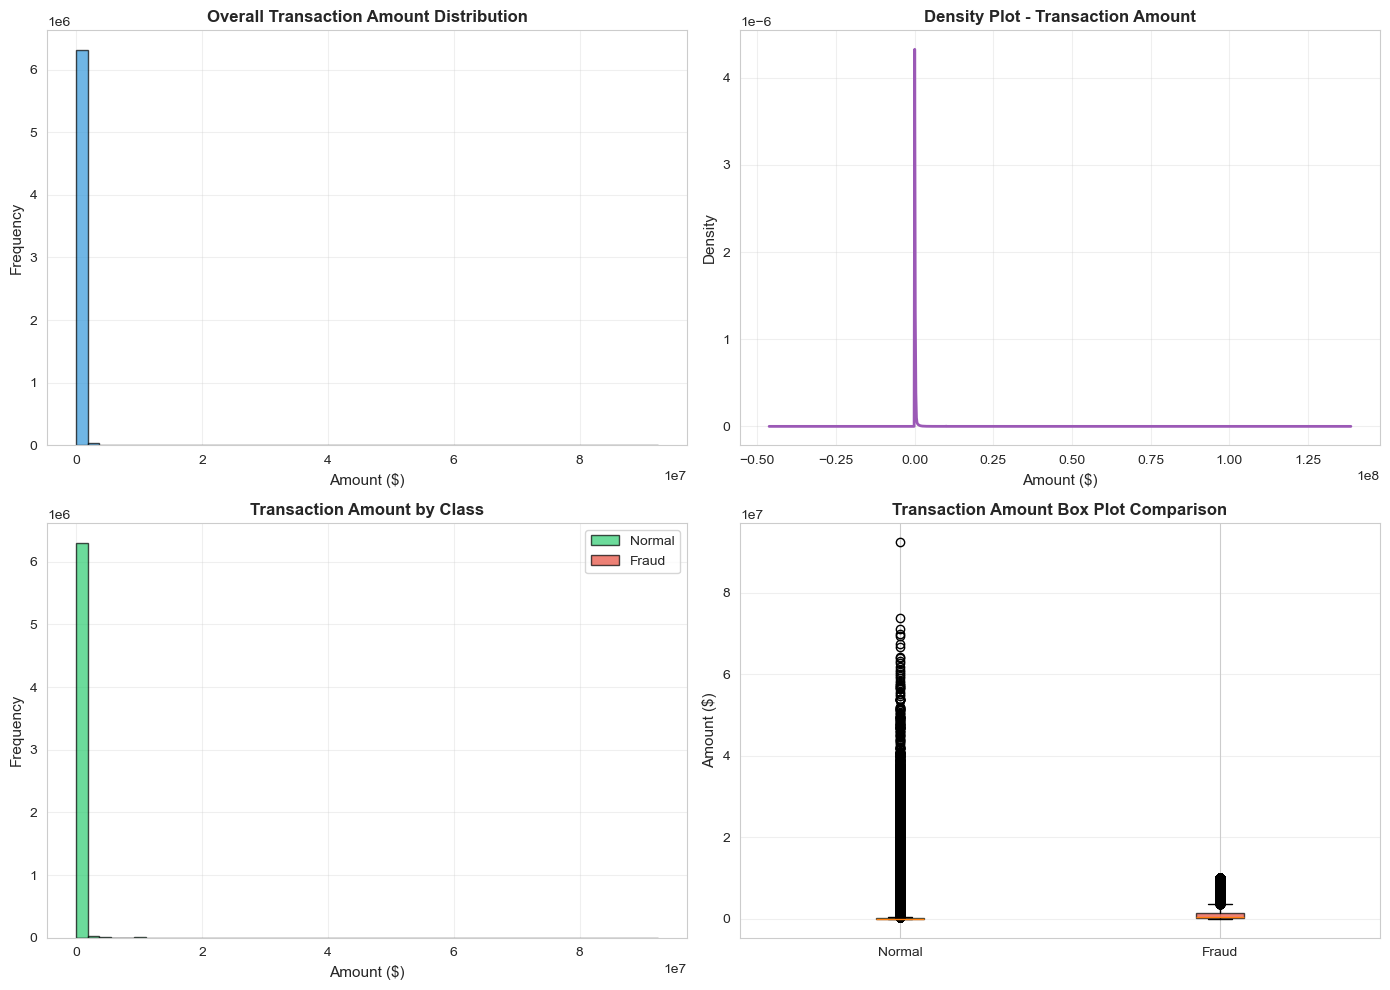


TRANSACTION AMOUNT STATISTICS

Normal Transactions:
  Mean: $178197.04
  Median: $74684.72
  Std Dev: $596236.98
  Min: $0.01, Max: $92445516.64

Fraud Transactions:
  Mean: $1467967.30
  Median: $441423.44
  Std Dev: $2404252.95
  Min: $0.00, Max: $10000000.00



In [7]:
def plot_amount_distribution(df: pd.DataFrame, target_column: str = 'isFraud', amount_column: str = 'amount') -> None:
    """
    Create distribution plots for transaction amounts by class.
    
    Args:
        df: Input DataFrame
        target_column: Name of the target column
        amount_column: Name of the amount column
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Overall distribution
    axes[0, 0].hist(df[amount_column], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Overall Transaction Amount Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Amount ($)', fontsize=11)
    axes[0, 0].set_ylabel('Frequency', fontsize=11)
    axes[0, 0].grid(alpha=0.3)
    
    # KDE plot for all transactions
    df[amount_column].plot(kind='density', ax=axes[0, 1], color='#9b59b6', linewidth=2)
    axes[0, 1].set_title('Density Plot - Transaction Amount', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Amount ($)', fontsize=11)
    axes[0, 1].set_ylabel('Density', fontsize=11)
    axes[0, 1].grid(alpha=0.3)
    
    # Distribution by class (separate)
    normal_transactions = df[df[target_column] == 0][amount_column]
    fraud_transactions = df[df[target_column] == 1][amount_column]
    
    axes[1, 0].hist(normal_transactions, bins=50, label='Normal', color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1, 0].hist(fraud_transactions, bins=50, label='Fraud', color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Transaction Amount by Class', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Amount ($)', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Box plot comparison
    box_data = [normal_transactions, fraud_transactions]
    bp = axes[1, 1].boxplot(box_data, labels=['Normal', 'Fraud'], patch_artist=True)
    colors = ['#2ecc71', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1, 1].set_title('Transaction Amount Box Plot Comparison', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Amount ($)', fontsize=11)
    axes[1, 1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*70)
    print("TRANSACTION AMOUNT STATISTICS")
    print("="*70)
    print(f"\nNormal Transactions:")
    print(f"  Mean: ${normal_transactions.mean():.2f}")
    print(f"  Median: ${normal_transactions.median():.2f}")
    print(f"  Std Dev: ${normal_transactions.std():.2f}")
    print(f"  Min: ${normal_transactions.min():.2f}, Max: ${normal_transactions.max():.2f}")
    
    print(f"\nFraud Transactions:")
    print(f"  Mean: ${fraud_transactions.mean():.2f}")
    print(f"  Median: ${fraud_transactions.median():.2f}")
    print(f"  Std Dev: ${fraud_transactions.std():.2f}")
    print(f"  Min: ${fraud_transactions.min():.2f}, Max: ${fraud_transactions.max():.2f}")
    print("="*70 + "\n")


# Plot amount distribution
plot_amount_distribution(df, target_column='isFraud', amount_column='amount')

## Section 6: Create Correlation Heatmap

Generate a correlation matrix and visualize it as a heatmap to identify feature relationships.


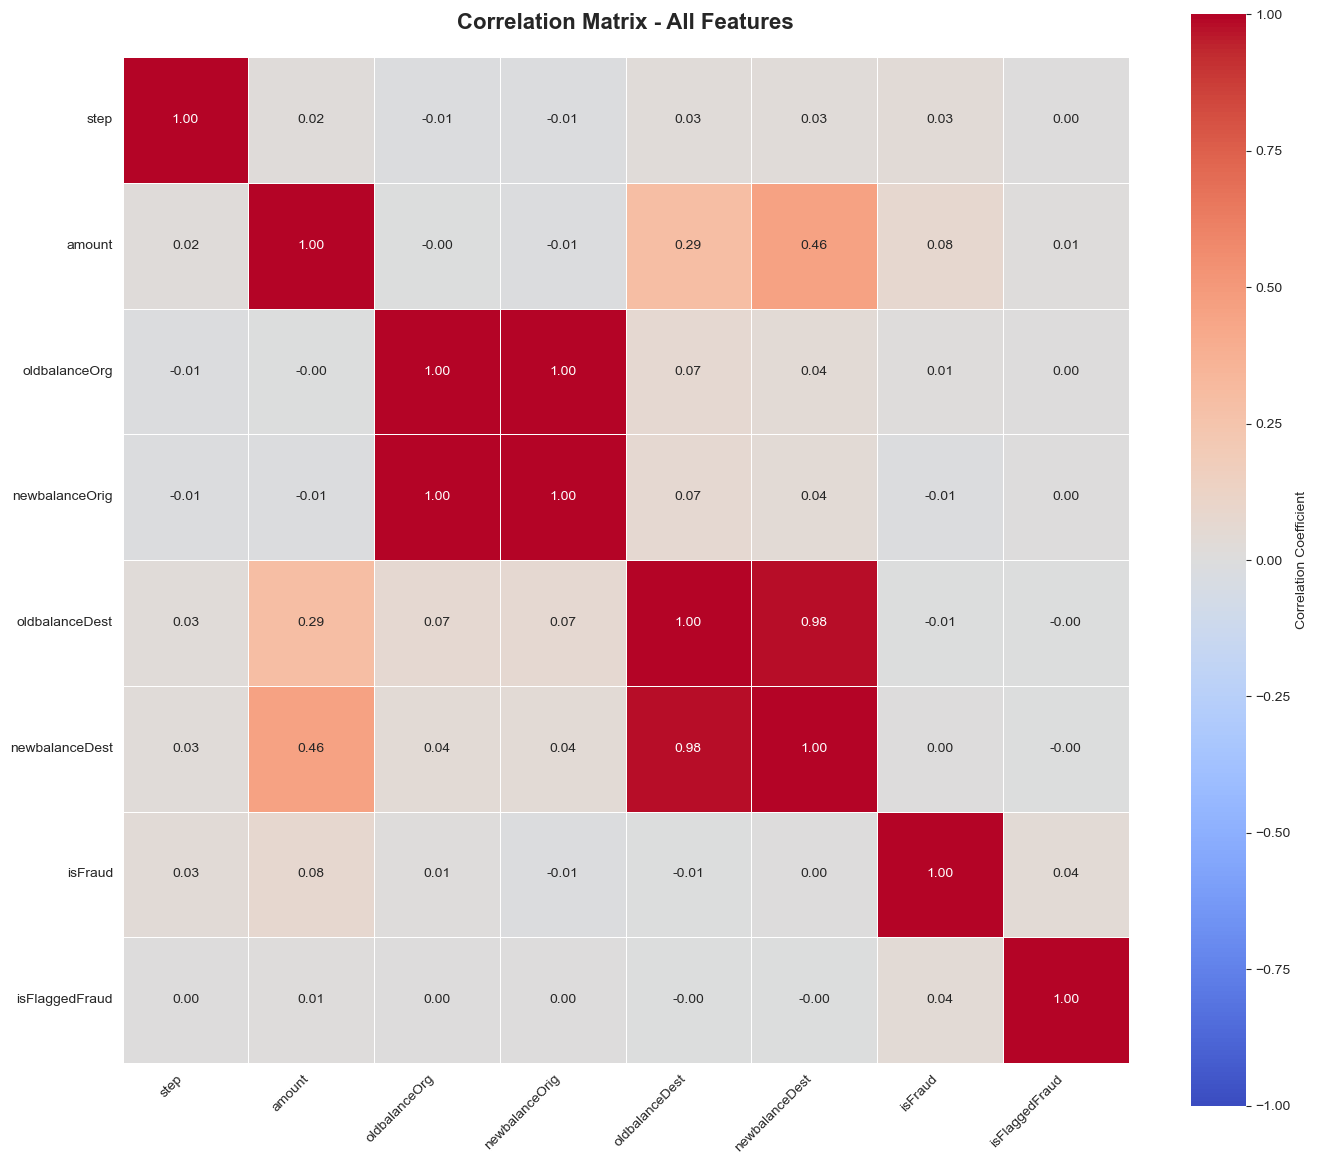

✓ Correlation heatmap generated


In [8]:
def plot_correlation_heatmap(df: pd.DataFrame, figsize: tuple = (14, 12)) -> None:
    """
    Create a correlation heatmap for numerical features.
    
    Args:
        df: Input DataFrame
        figsize: Figure size
    """
    # Calculate correlation matrix
    correlation_matrix = df.corr(numeric_only=True)
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.heatmap(correlation_matrix, 
                annot=True, 
                fmt='.2f', 
                cmap='coolwarm', 
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={'label': 'Correlation Coefficient'},
                ax=ax,
                vmin=-1, 
                vmax=1)
    
    ax.set_title('Correlation Matrix - All Features', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("✓ Correlation heatmap generated")


# Plot correlation heatmap
plot_correlation_heatmap(df)

## Summary & Key Insights

This exploratory data analysis provides:

✅ **Data Overview**: Basic statistics and structure of the dataset
✅ **Class Analysis**: Understanding the fraud vs non-fraud distribution and class imbalance
✅ **Distribution Analysis**: How transaction amounts differ between fraud and normal transactions
✅ **Correlation Analysis**: Identifying feature relationships that may influence model performance

### Next Steps:
1. **Feature Engineering**: Create and select important features
2. **Data Preprocessing**: Handle class imbalance using SMOTE or weighted models
3. **Model Training**: Train classification models using the balanced dataset
4. **Model Evaluation**: Evaluate with appropriate metrics (precision, recall, F1, ROC-AUC)
5. **Hyperparameter Tuning**: Optimize model performance
6. **Deployment**: Create predictions on new data using the trained model
